In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

df = pd.read_csv(r'C:\Users\namra\OneDrive\Desktop\netflix-eda\data\netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
# Shape & missing values
print("Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())

# Fill missing values
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)
df['rating'].fillna(df['rating'].mode()[0], inplace=True)
df['date_added'].fillna('Unknown', inplace=True)

# Convert date_added to datetime
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

# Clean duration column
df['duration_int'] = df['duration'].str.extract(r'(\d+)').astype(float)

print("\n✅ Cleaning Done! Remaining nulls:\n", df.isnull().sum())

Shape: (8807, 12)

Missing Values:
 show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

✅ Cleaning Done! Remaining nulls:
 show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      98
release_year     0
rating           0
duration         3
listed_in        0
description      0
year_added      98
month_added     98
duration_int     3
dtype: int64


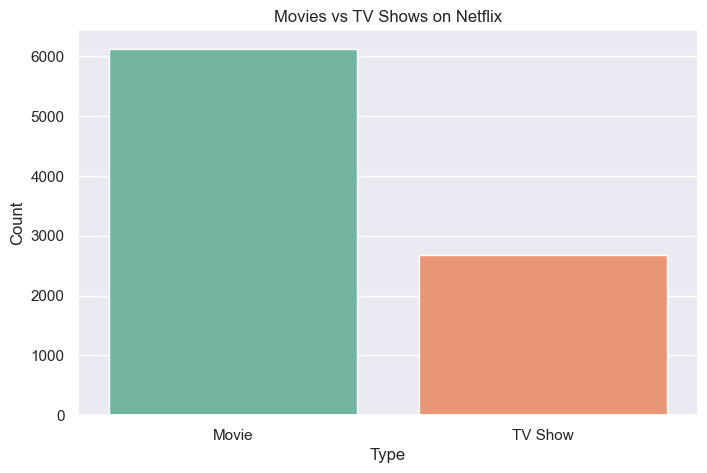

In [6]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='type', palette='Set2')
plt.title('Movies vs TV Shows on Netflix')
plt.xlabel('Type')
plt.ylabel('Count')
plt.savefig(r'C:\Users\namra\OneDrive\Desktop\netflix-eda\images\01_movies_vs_tvshows.png', bbox_inches='tight')
plt.show()

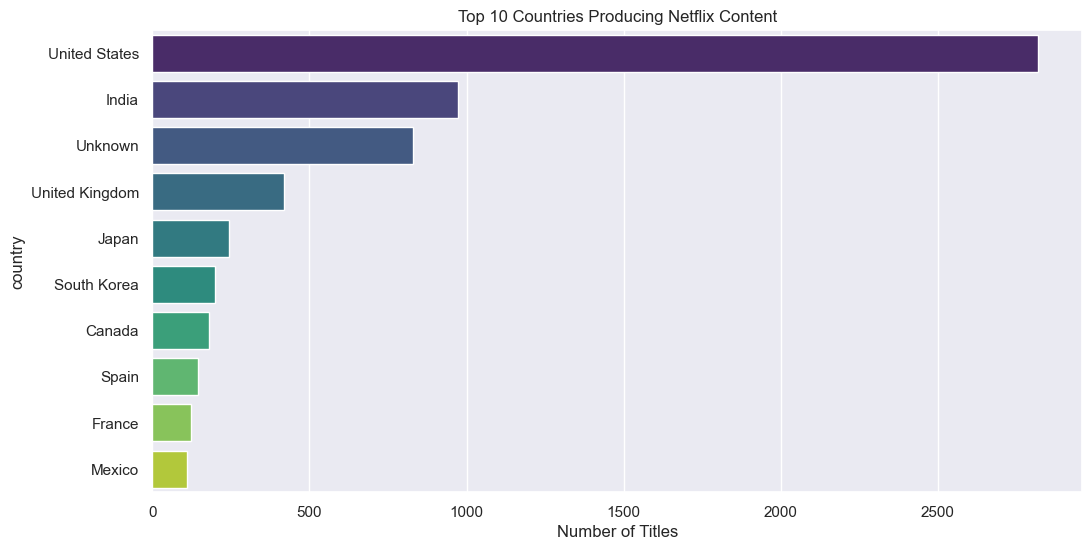

In [7]:
top_countries = df['country'].value_counts().head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title('Top 10 Countries Producing Netflix Content')
plt.xlabel('Number of Titles')
plt.savefig(r'C:\Users\namra\OneDrive\Desktop\netflix-eda\images\02_top_countries.png', bbox_inches='tight')
plt.show()

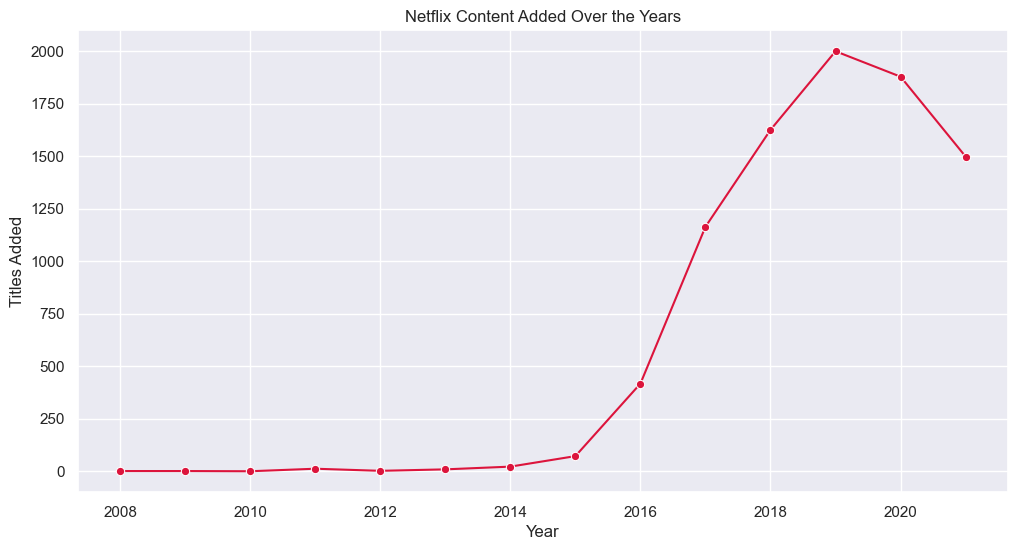

In [8]:
yearly = df['year_added'].value_counts().sort_index()
plt.figure(figsize=(12,6))
sns.lineplot(x=yearly.index, y=yearly.values, marker='o', color='crimson')
plt.title('Netflix Content Added Over the Years')
plt.xlabel('Year')
plt.ylabel('Titles Added')
plt.savefig(r'C:\Users\namra\OneDrive\Desktop\netflix-eda\images\03_content_over_years.png', bbox_inches='tight')
plt.show()

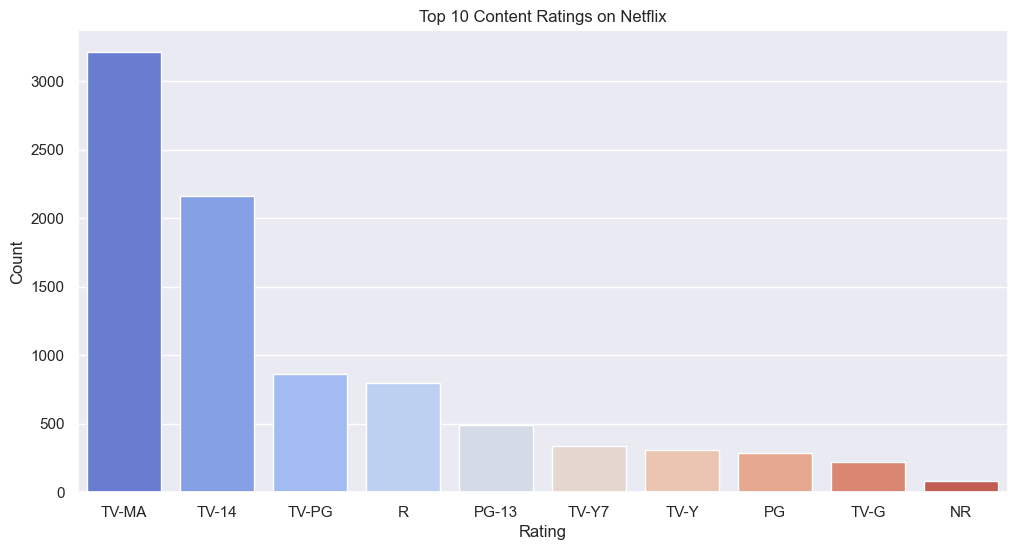

In [9]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='rating', order=df['rating'].value_counts().index[:10], palette='coolwarm')
plt.title('Top 10 Content Ratings on Netflix')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.savefig(r'C:\Users\namra\OneDrive\Desktop\netflix-eda\images\04_ratings.png', bbox_inches='tight')
plt.show()

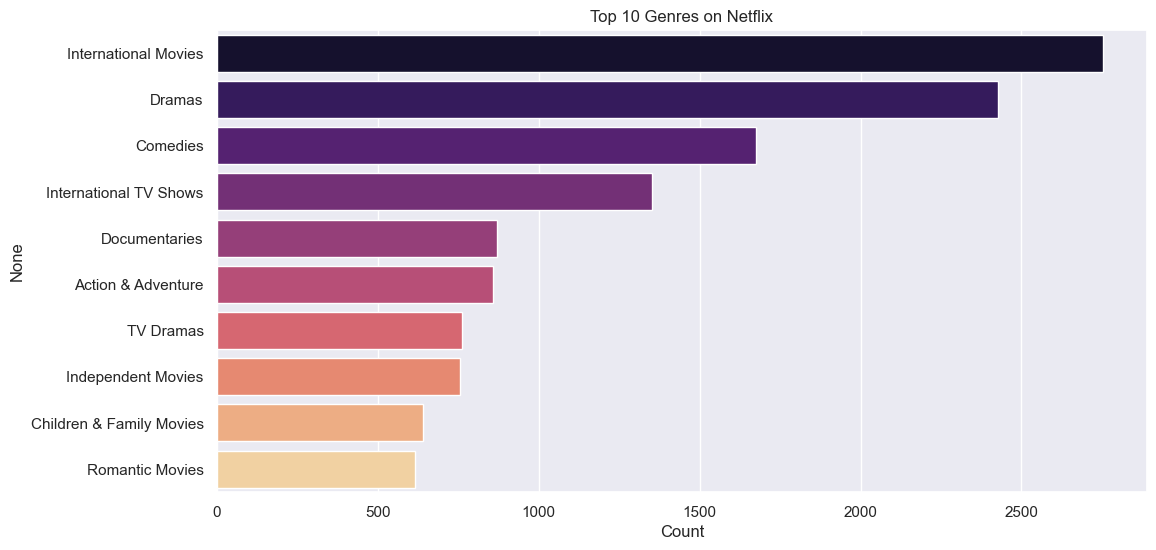

In [10]:
from collections import Counter
genres = df['listed_in'].str.split(', ').explode()
top_genres = pd.Series(Counter(genres)).sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='magma')
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Count')
plt.savefig(r'C:\Users\namra\OneDrive\Desktop\netflix-eda\images\05_top_genres.png', bbox_inches='tight')
plt.show()

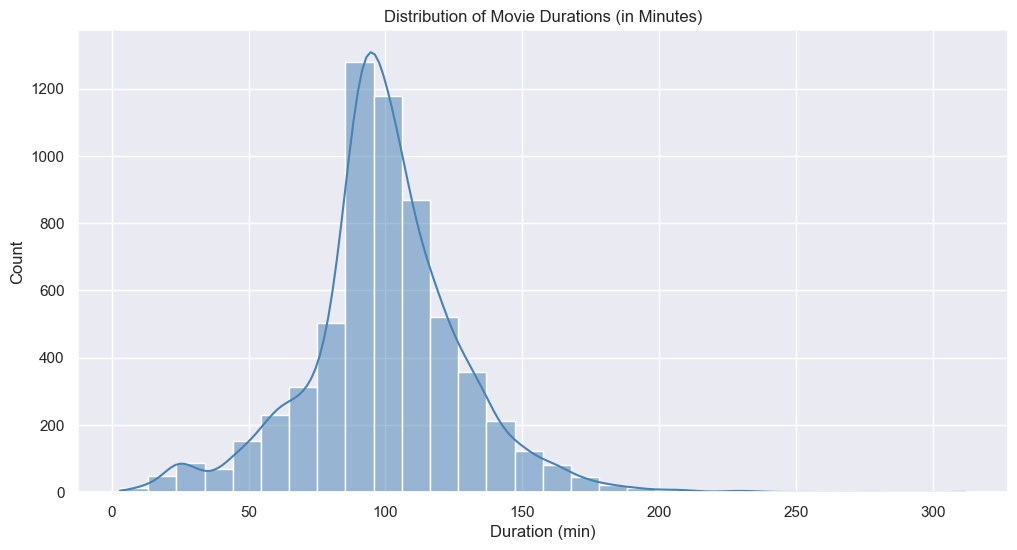

In [11]:
movies = df[df['type'] == 'Movie']
plt.figure(figsize=(12,6))
sns.histplot(movies['duration_int'].dropna(), bins=30, kde=True, color='steelblue')
plt.title('Distribution of Movie Durations (in Minutes)')
plt.xlabel('Duration (min)')
plt.savefig(r'C:\Users\namra\OneDrive\Desktop\netflix-eda\images\06_movie_duration.png', bbox_inches='tight')
plt.show()

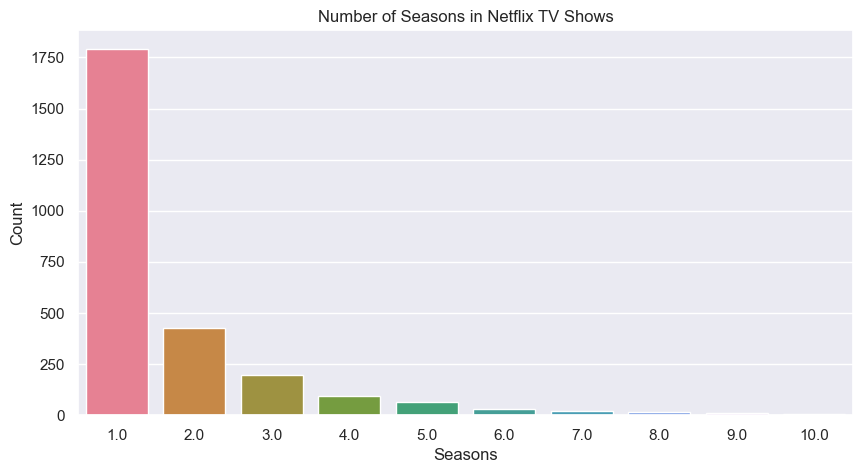

In [12]:
tvshows = df[df['type'] == 'TV Show']
plt.figure(figsize=(10,5))
sns.countplot(data=tvshows, x='duration_int', palette='husl', 
              order=tvshows['duration_int'].value_counts().index[:10])
plt.title('Number of Seasons in Netflix TV Shows')
plt.xlabel('Seasons')
plt.ylabel('Count')
plt.savefig(r'C:\Users\namra\OneDrive\Desktop\netflix-eda\images\07_tvshow_seasons.png', bbox_inches='tight')
plt.show()

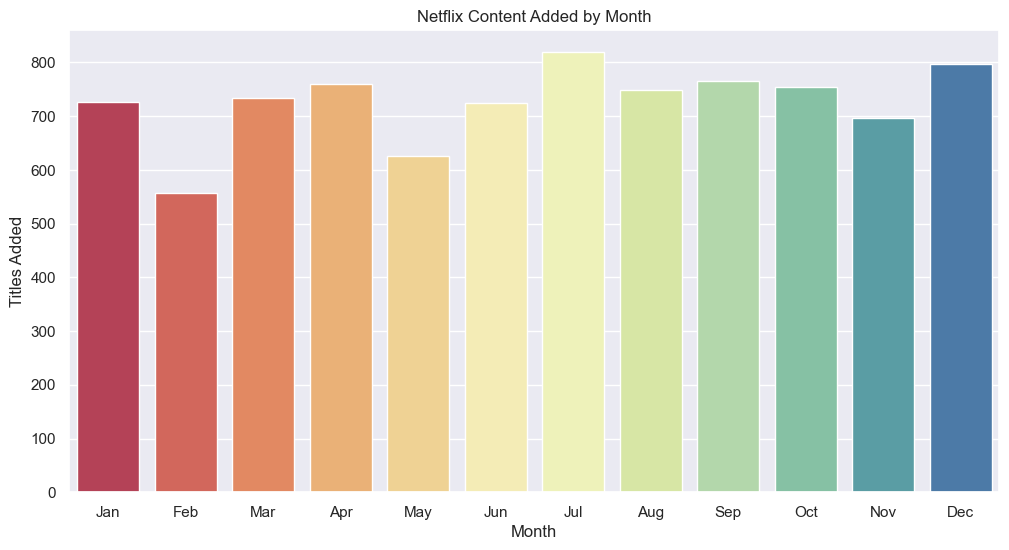

In [13]:
month_map = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
             7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
monthly = df['month_added'].value_counts().sort_index()
plt.figure(figsize=(12,6))
sns.barplot(x=list(month_map.values()), y=monthly.values, palette='Spectral')
plt.title('Netflix Content Added by Month')
plt.xlabel('Month')
plt.ylabel('Titles Added')
plt.savefig(r'C:\Users\namra\OneDrive\Desktop\netflix-eda\images\08_content_by_month.png', bbox_inches='tight')
plt.show()

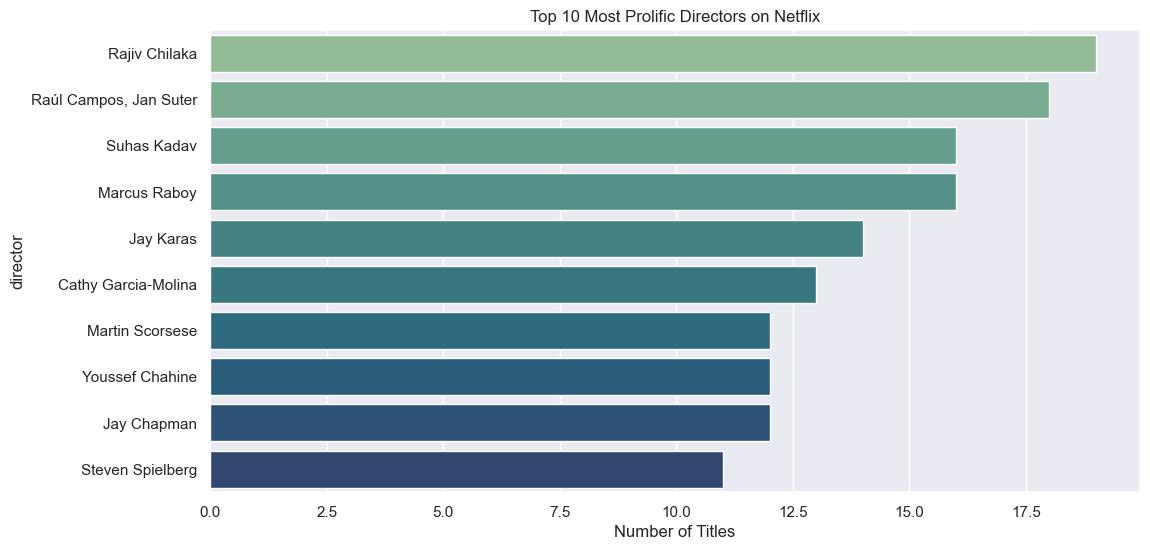

In [14]:
top_directors = df[df['director'] != 'Unknown']['director'].value_counts().head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=top_directors.values, y=top_directors.index, palette='crest')
plt.title('Top 10 Most Prolific Directors on Netflix')
plt.xlabel('Number of Titles')
plt.savefig(r'C:\Users\namra\OneDrive\Desktop\netflix-eda\images\09_top_directors.png', bbox_inches='tight')
plt.show()

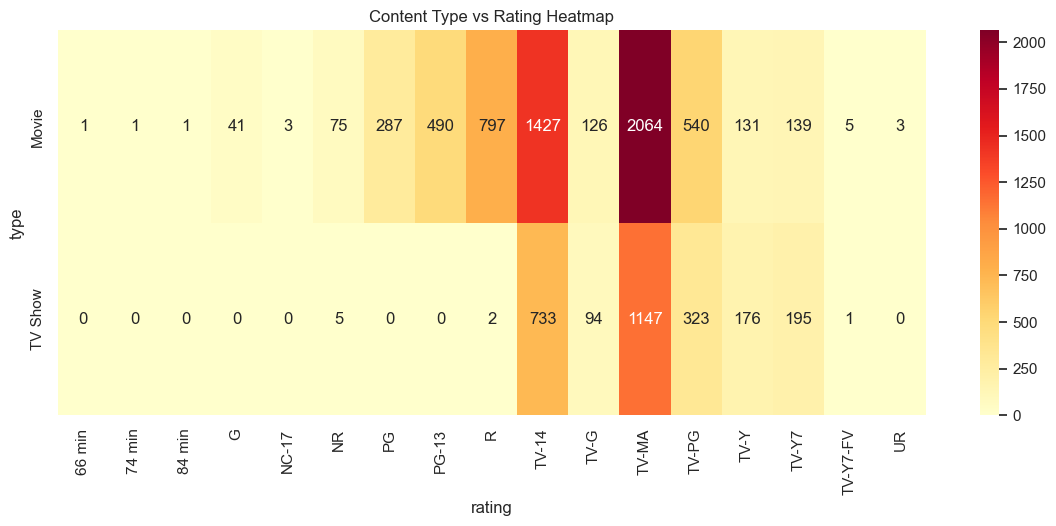

In [15]:
pivot = df.groupby(['type','rating']).size().unstack(fill_value=0)
plt.figure(figsize=(14,5))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Content Type vs Rating Heatmap')
plt.savefig(r'C:\Users\namra\OneDrive\Desktop\netflix-eda\images\10_type_vs_rating_heatmap.png', bbox_inches='tight')
plt.show()